# NB3 — Feature Engineering, UMAP & Classification (Lab Data)

**Differences from N-CMAPSS:**
- **7 classes** (no SystemFault): Nominal, Bias, Scaling, Drift, Intermittent, Compound, MultiSensor
- Smaller models: ANN `[128,64,32]`, LSTM `hidden=64`, Transformer `d_model=32`
- `n_sensors=29`, `window_size=100`
- Staircase data → UMAP may show multiple Nominal clusters (one per speed step) — expected


## 0 — Imports & configuration

In [1]:
import sys, os, gc, pickle, warnings, logging, json
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')

import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

sys.path.insert(0, '..')
from models import (
    ConvAutoencoder, AETrainer,
    MultiHeadANN,         ANNTrainer,
    MultiHeadLSTM,        SequenceTrainer,
    MultiHeadTransformer,
    MCDropoutWrapper,
    DEVICE,
)
from feature_engineering import FeaturePipeline
from lab_data_utils      import LAB_FAULT_LABELS

PROC_DIR = '../processed_data'
CKPT_DIR = '../checkpoints'
PLOT_DIR = '../plots'

label_names = LAB_FAULT_LABELS

# HEAD_TYPE: 'ANN' | 'LSTM' | 'Transformer' | 'all'
HEAD_TYPE    = 'all'
USE_RESIDUAL = True

print(f'Device   : {DEVICE}')
print(f'HEAD_TYPE: {HEAD_TYPE}')

2026-04-22 13:24:51,326 [INFO] NumExpr defaulting to 12 threads.
2026-04-22 13:24:51,765 [INFO] GPU: NVIDIA RTX 4500 Ada Generation


Device   : cuda
HEAD_TYPE: all


## 1 — Load NB1 + NB2 outputs

In [2]:
with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f:
    sensor_cols = pickle.load(f)
with open(f'{PROC_DIR}/sensor_display_names.pkl', 'rb') as f:
    display_names = pickle.load(f)
with open(f'{CKPT_DIR}/lab_meta.json') as f:
    meta = json.load(f)

N_SENSORS     = meta['n_sensors']       # 29
WINDOW_SIZE   = meta['window_size']     # 100
N_FAULT_TYPES = meta['n_fault_types']   # 7

_d = np.load(f'{PROC_DIR}/augmented_dataset.npz')
X_dataset = _d['X']; y_fault = _d['y_f']
y_sensor  = _d['y_s']; y_mag = _d['y_m']

X_nominal = np.load(f'{PROC_DIR}/X_nominal.npy')

# Load AE
ae_model = ConvAutoencoder(
    n_sensors=N_SENSORS, window_size=WINDOW_SIZE,
    base_ch=16, latent_dim=32, dropout_p=0.20
).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt',
                                     map_location=DEVICE, weights_only=True))
ae_model.eval()
ae_trainer = AETrainer(ae_model, device=DEVICE)

print(f'X_nominal : {X_nominal.shape}')
print(f'X_dataset : {X_dataset.shape}')
print(f'Classes   : {list(label_names.values())}')

2026-04-22 13:24:59,643 [INFO] AE Bottleneck: 1664 -> 32 -> 1664


X_nominal : (16022, 100, 29)
X_dataset : (112154, 100, 29)
Classes   : ['Nominal', 'Bias', 'Scaling', 'Drift', 'Intermittent', 'Compound', 'MultiSensor']


## 2 — Hyperparameters (smaller than N-CMAPSS)

In [3]:
# ── ANN ──────────────────────────────────────────────────────────────────────
N_FFT_PEAKS   = 3
N_UMAP_COMP   = 2
ANN_HIDDEN    = [128, 64, 32]   # N-CMAPSS: [256, 128, 64]
ANN_EPOCHS    = 100
ANN_LR        = 5e-4

# ── LSTM ─────────────────────────────────────────────────────────────────────
LSTM_HIDDEN   = 64     # N-CMAPSS: 128
LSTM_LAYERS   = 2
LSTM_EPOCHS   = 150
LSTM_LR       = 2e-4
LSTM_PATIENCE = 20
LSTM_WARMUP   = 0

# ── Transformer ──────────────────────────────────────────────────────────────
TF_D_MODEL    = 32     # N-CMAPSS: 64
TF_NHEAD      = 4      # d_model must be divisible by nhead
TF_LAYERS     = 2
TF_FFN_DIM    = 128    # N-CMAPSS: 256
TF_EPOCHS     = 150
TF_LR         = 2e-4
TF_PATIENCE   = 20
TF_WARMUP     = 5

# ── Shared ───────────────────────────────────────────────────────────────────
BATCH_SIZE      = 256
DROPOUT_P_ANN   = 0.3
DROPOUT_P_SEQ   = 0.1
MC_T            = 100
MAX_FIT_SAMPLES = 10_000   # cap UMAP fit (lab data is smaller)
RECON_BATCH     = 256

print('Hyperparameters set.')
print(f'  ANN hidden : {ANN_HIDDEN}')
print(f'  LSTM hidden: {LSTM_HIDDEN}  (d_model={LSTM_HIDDEN*2})')
print(f'  TF d_model : {TF_D_MODEL}')

Hyperparameters set.
  ANN hidden : [128, 64, 32]
  LSTM hidden: 64  (d_model=128)
  TF d_model : 32


## 3 — AE reconstruction cache

In [4]:
recon_cache = f'{PROC_DIR}/augmented_dataset_with_recon.npz'

if os.path.exists(recon_cache):
    _d2 = np.load(recon_cache)
    X_recon_all = _d2['X_rec']
    if len(X_recon_all) != len(X_dataset):
        print(f'Cache mismatch ({len(X_recon_all)} vs {len(X_dataset)}) — rebuilding.')
        os.remove(recon_cache)
        X_recon_all = None
    else:
        print(f'Loaded cached reconstructions: {X_recon_all.shape}')

if not os.path.exists(recon_cache):
    print(f'Reconstructing {len(X_dataset):,} windows …')
    X_recon_all = np.zeros_like(X_dataset)
    for i in tqdm(range(0, len(X_dataset), RECON_BATCH), desc='AE reconstruct'):
        X_recon_all[i:i+RECON_BATCH] = ae_trainer.reconstruct(X_dataset[i:i+RECON_BATCH])
    np.savez_compressed(recon_cache, X=X_dataset, X_rec=X_recon_all,
                        y_f=y_fault, y_s=y_sensor, y_m=y_mag)
    print(f'Saved reconstruction cache.')

print(f'X_dataset   : {X_dataset.shape}')
print(f'X_recon_all : {X_recon_all.shape}')

Reconstructing 112,154 windows …


AE reconstruct: 100%|██████████| 439/439 [00:04<00:00, 109.18it/s]


Saved reconstruction cache.
X_dataset   : (112154, 100, 29)
X_recon_all : (112154, 100, 29)


## 4a — ANN path: UMAP + feature engineering

**Note on UMAP with staircase data:** You will likely see multiple Nominal clusters
in the UMAP plot — one per speed step. This is correct behaviour, not a bug.
The ANN should still separate fault types from these multi-modal nominal clusters.

In [5]:
if HEAD_TYPE in ('ANN', 'all'):
    feat_pipe = FeaturePipeline(
        n_components       = N_UMAP_COMP,
        n_fft_peaks        = N_FFT_PEAKS,
        cluster_percentile = 95,
    )
    feat_pipe.projector.method = 'UMAP'

    X_nom_sub = X_nominal[:min(MAX_FIT_SAMPLES, len(X_nominal))]
    X_recon_sub = ae_trainer.reconstruct(X_nom_sub)
    print(f'Fitting UMAP on {len(X_nom_sub):,} nominal windows …')
    feat_pipe.fit(X_nom_sub, X_recon_nominal=X_recon_sub)
    print('Pipeline fitted.')

    CHUNK = 2000   # smaller chunks for lab data
    F_chunks, Z_chunks, sev_chunks, conf_chunks = [], [], [], []
    for i in tqdm(range(0, len(X_dataset), CHUNK), desc='Feature transform'):
        xb  = X_dataset[i:i+CHUNK]
        xrb = X_recon_all[i:i+CHUNK]
        F_b, Z_b, sev_b, conf_b = feat_pipe.transform(xb, X_recon=xrb)
        F_chunks.append(F_b); Z_chunks.append(Z_b)
        sev_chunks.append(sev_b); conf_chunks.append(conf_b)
        gc.collect()

    F_all    = np.concatenate(F_chunks).astype(np.float32)
    Z_all    = np.concatenate(Z_chunks).astype(np.float32)
    sev_all  = np.concatenate(sev_chunks).astype(np.float32)
    conf_all = np.concatenate(conf_chunks).astype(np.float32)

    np.savez_compressed(f'{PROC_DIR}/final_manifold_features.npz',
                        F=F_all, Z=Z_all, sev=sev_all, conf=conf_all,
                        y_f=y_fault, y_s=y_sensor, y_m=y_mag)
    with open(f'{CKPT_DIR}/feature_pipeline.pkl', 'wb') as f:
        pickle.dump(feat_pipe, f)
    print(f'F_all shape: {F_all.shape}')
else:
    print('Skipping ANN feature engineering.')

Fitting UMAP on 10,000 nominal windows …


2026-04-22 13:28:16,573 [INFO] ManifoldProjector: fitted UMAP (n_comp=2)
2026-04-22 13:28:16,624 [INFO] NominalCluster fitted | center=[6.514488 2.396331] | R_95=2.1538


Pipeline fitted.


Feature transform: 100%|██████████| 57/57 [03:08<00:00,  3.31s/it]


F_all shape: (112154, 406)


### 4b — UMAP manifold plot
Multiple Nominal clusters = different speed steps. This is expected for staircase data.

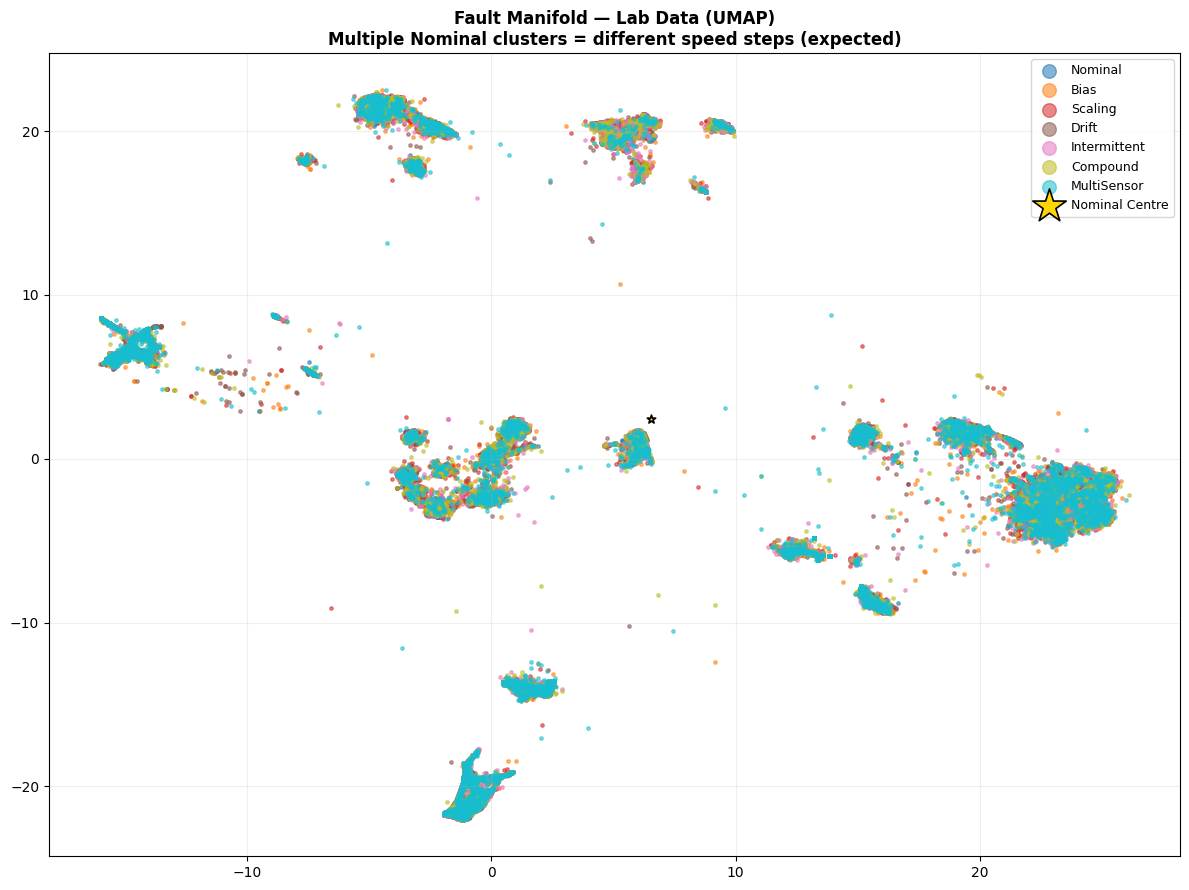

In [6]:
if HEAD_TYPE in ('ANN', 'all') and 'Z_all' in dir():
    cmap_ = plt.cm.get_cmap('tab10', N_FAULT_TYPES)
    fig, ax = plt.subplots(figsize=(12, 9))
    for lbl in np.unique(y_fault):
        m = y_fault == lbl
        ax.scatter(Z_all[m, 0], Z_all[m, 1], c=[cmap_(lbl)],
                   label=label_names.get(lbl, str(lbl)), s=6, alpha=0.55, rasterized=True)
    cx, cy = feat_pipe.cluster.center_
    ax.scatter(cx, cy, marker='*', s=40, c='gold', edgecolors='black',
               linewidths=1.2, zorder=10, label='Nominal Centre')
    ax.set_title('Fault Manifold — Lab Data (UMAP)\n'
                 'Multiple Nominal clusters = different speed steps (expected)',
                 fontsize=12, fontweight='bold')
    ax.legend(markerscale=4, fontsize=9); ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb3_lab_manifold.png', dpi=130)
    plt.show()

## 5a — Train ANN

In [7]:
ann_val_losses = None
if HEAD_TYPE in ('ANN', 'all'):
    n_features = F_all.shape[1]
    ann_model  = MultiHeadANN(
        in_features   = n_features,
        n_fault_types = N_FAULT_TYPES,
        n_sensors     = len(sensor_cols),
        hidden_dims   = ANN_HIDDEN,
        dropout_p     = DROPOUT_P_ANN,
    )
    print(f'ANN: {n_features} features, {sum(p.numel() for p in ann_model.parameters()):,} params')
    ann_trainer    = ANNTrainer(ann_model, lr=ANN_LR, device=DEVICE)
    ann_val_losses = ann_trainer.fit(
        F_all, y_fault, y_sensor, y_mag,
        epochs=ANN_EPOCHS, batch_size=BATCH_SIZE,
    )
    torch.save(ann_model.state_dict(), f'{CKPT_DIR}/ann_multihead.pt')
    print(f'ANN saved. Best val loss: {min(ann_val_losses):.4f}')
else:
    print('Skipping ANN.')

ANN: 406 features, 65,157 params


2026-04-22 13:32:02,811 [INFO] ANN Epoch  10/100 | val_loss=1.5609
2026-04-22 13:32:30,491 [INFO] ANN Epoch  20/100 | val_loss=1.2591
2026-04-22 13:32:58,895 [INFO] ANN Epoch  30/100 | val_loss=1.0833
2026-04-22 13:33:26,593 [INFO] ANN Epoch  40/100 | val_loss=1.0113
2026-04-22 13:33:55,760 [INFO] ANN Epoch  50/100 | val_loss=1.0138
2026-04-22 13:34:23,938 [INFO] ANN Epoch  60/100 | val_loss=0.9667
2026-04-22 13:34:51,415 [INFO] ANN Epoch  70/100 | val_loss=0.9480
2026-04-22 13:35:19,176 [INFO] ANN Epoch  80/100 | val_loss=0.9203
2026-04-22 13:35:47,888 [INFO] ANN Epoch  90/100 | val_loss=0.9180
2026-04-22 13:36:15,411 [INFO] ANN Epoch 100/100 | val_loss=0.8931


ANN saved. Best val loss: 0.8931


## 5b — Train LSTM

In [8]:
lstm_val_losses = None
if HEAD_TYPE in ('LSTM', 'all'):
    lstm_model = MultiHeadLSTM(
        n_sensors     = N_SENSORS,
        hidden_size   = LSTM_HIDDEN,
        num_layers    = LSTM_LAYERS,
        n_fault_types = N_FAULT_TYPES,
        dropout_p     = DROPOUT_P_ANN,
        use_residual  = USE_RESIDUAL,
    )
    print(f'LSTM: {sum(p.numel() for p in lstm_model.parameters()):,} params')
    lstm_trainer    = SequenceTrainer(lstm_model, lr=LSTM_LR, device=DEVICE, warmup_epochs=LSTM_WARMUP)
    lstm_val_losses = lstm_trainer.fit(
        X_dataset, y_fault, y_sensor, y_mag,
        X_recon=X_recon_all if USE_RESIDUAL else None,
        epochs=LSTM_EPOCHS, batch_size=BATCH_SIZE, patience=LSTM_PATIENCE,
    )
    torch.save(lstm_model.state_dict(), f'{CKPT_DIR}/lstm_multihead.pt')
    print(f'LSTM saved. Best val loss: {min(lstm_val_losses):.4f}')
else:
    print('Skipping LSTM.')

LSTM: 179,365 params


2026-04-22 13:37:49,730 [INFO] MultiHeadLSTM Epoch  10/150 | train=1.1167 | val=1.0011
2026-04-22 13:39:21,631 [INFO] MultiHeadLSTM Epoch  20/150 | train=0.8672 | val=0.8629
2026-04-22 13:40:55,332 [INFO] MultiHeadLSTM Epoch  30/150 | train=0.7524 | val=0.7657
2026-04-22 13:42:28,816 [INFO] MultiHeadLSTM Epoch  40/150 | train=0.6862 | val=0.7146
2026-04-22 13:44:00,216 [INFO] MultiHeadLSTM Epoch  50/150 | train=0.6421 | val=0.6415
2026-04-22 13:45:31,734 [INFO] MultiHeadLSTM Epoch  60/150 | train=0.6038 | val=0.6166
2026-04-22 13:47:03,924 [INFO] MultiHeadLSTM Epoch  70/150 | train=0.5774 | val=0.6310
2026-04-22 13:48:36,185 [INFO] MultiHeadLSTM Epoch  80/150 | train=0.5537 | val=0.6056
2026-04-22 13:50:08,669 [INFO] MultiHeadLSTM Epoch  90/150 | train=0.5322 | val=0.5812
2026-04-22 13:51:40,477 [INFO] MultiHeadLSTM Epoch 100/150 | train=0.5145 | val=0.5831
2026-04-22 13:53:11,823 [INFO] MultiHeadLSTM Epoch 110/150 | train=0.5021 | val=0.5842
2026-04-22 13:54:43,788 [INFO] MultiHeadLST

LSTM saved. Best val loss: 0.5769


## 5c — Train Transformer

In [9]:
tf_val_losses = None
if HEAD_TYPE in ('Transformer', 'all'):
    tf_model = MultiHeadTransformer(
        n_sensors      = N_SENSORS,
        d_model        = TF_D_MODEL,
        nhead          = TF_NHEAD,
        num_layers     = TF_LAYERS,
        dim_feedforward= TF_FFN_DIM,
        n_fault_types  = N_FAULT_TYPES,
        dropout_p      = DROPOUT_P_SEQ,
        use_residual   = USE_RESIDUAL,
        store_attn     = True,
    )
    print(f'Transformer: {sum(p.numel() for p in tf_model.parameters()):,} params')
    tf_trainer    = SequenceTrainer(tf_model, lr=TF_LR, device=DEVICE, warmup_epochs=TF_WARMUP)
    tf_val_losses = tf_trainer.fit(
        X_dataset, y_fault, y_sensor, y_mag,
        X_recon=X_recon_all if USE_RESIDUAL else None,
        epochs=TF_EPOCHS, batch_size=BATCH_SIZE, patience=TF_PATIENCE,
    )
    torch.save(tf_model.state_dict(), f'{CKPT_DIR}/transformer_multihead.pt')
    print(f'Transformer saved. Best val loss: {min(tf_val_losses):.4f}')
else:
    print('Skipping Transformer.')

Transformer: 29,829 params


2026-04-22 14:00:00,507 [INFO] MultiHeadTransformer Epoch  10/150 | train=1.4831 | val=1.4472
2026-04-22 14:02:11,022 [INFO] MultiHeadTransformer Epoch  20/150 | train=1.1407 | val=1.1971
2026-04-22 14:04:21,293 [INFO] MultiHeadTransformer Epoch  30/150 | train=0.9926 | val=1.1694
2026-04-22 14:06:07,610 [INFO] MultiHeadTransformer Epoch  40/150 | train=0.9083 | val=1.0715
2026-04-22 14:07:16,294 [INFO] MultiHeadTransformer Epoch  50/150 | train=0.8566 | val=1.0429
2026-04-22 14:08:26,393 [INFO] MultiHeadTransformer Epoch  60/150 | train=0.8157 | val=1.0243
2026-04-22 14:09:35,253 [INFO] MultiHeadTransformer Epoch  70/150 | train=0.7886 | val=0.9867
2026-04-22 14:10:44,160 [INFO] MultiHeadTransformer Epoch  80/150 | train=0.7689 | val=0.9481
2026-04-22 14:11:58,181 [INFO] MultiHeadTransformer Epoch  90/150 | train=0.7512 | val=0.9607
2026-04-22 14:13:35,036 [INFO] MultiHeadTransformer Epoch 100/150 | train=0.7387 | val=0.9143
2026-04-22 14:14:43,465 [INFO] MultiHeadTransformer Epoch 11

Transformer saved. Best val loss: 0.9103


## 6 — Training curve comparison

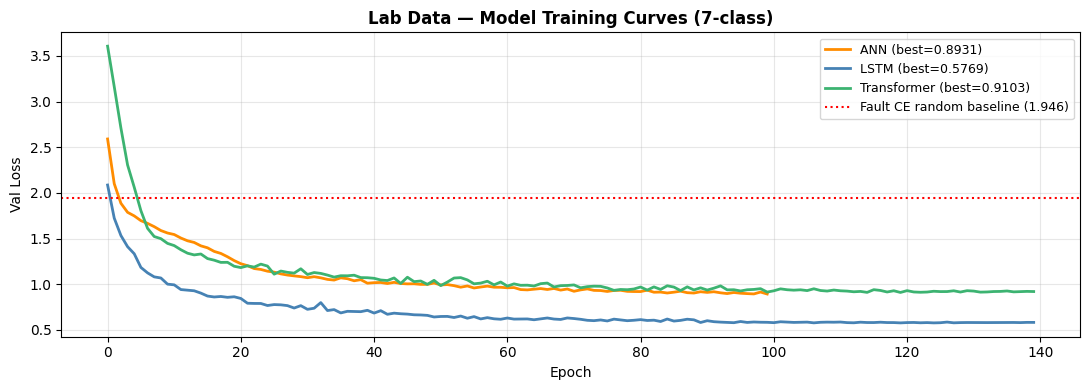

Best val losses: [('ANN', '0.8931'), ('LSTM', '0.5769'), ('Transformer', '0.9103')]


In [10]:
curves = {'ANN': (ann_val_losses,'darkorange'), 'LSTM': (lstm_val_losses,'steelblue'),
          'Transformer': (tf_val_losses,'mediumseagreen')}
active = {k: v for k, v in curves.items() if v[0] is not None}
if active:
    import math
    random_baseline = math.log(N_FAULT_TYPES)  # 7-class random CE
    fig, ax = plt.subplots(figsize=(11, 4))
    for name, (losses, color) in active.items():
        ax.plot(losses, lw=2, color=color, label=f'{name} (best={min(losses):.4f})')
    ax.axhline(random_baseline, color='red', ls=':', lw=1.5,
               label=f'Fault CE random baseline ({random_baseline:.3f})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss')
    ax.set_title('Lab Data — Model Training Curves (7-class)', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb3_lab_training_curves.png', dpi=120)
    plt.show()
    print(f'Best val losses: {[(k, f"{min(v[0]):.4f}") for k, v in active.items()]}')

## 7 — MC Dropout + per-class accuracy (stratified test set)

In [11]:
# Stratified sampling — guarantees all 7 classes represented
_, idx_test = train_test_split(
    np.arange(len(X_dataset)),
    test_size   = min(500, len(X_dataset)),
    stratify    = y_fault,
    random_state= 42,
)
idx_test = np.array(idx_test)

X_raw_test = X_dataset[idx_test]
X_rec_test = X_recon_all[idx_test]
if USE_RESIDUAL:
    X_seq_test = np.concatenate([X_raw_test, np.abs(X_raw_test - X_rec_test)], axis=-1)
else:
    X_seq_test = X_raw_test
seq_t = torch.from_numpy(X_seq_test).float().to(DEVICE)

mc_results = {}
if HEAD_TYPE in ('ANN', 'all') and ann_val_losses is not None:
    F_test = torch.from_numpy(F_all[idx_test]).float().to(DEVICE)
    mc_ann = MCDropoutWrapper(ann_model, T=MC_T)
    mc_results['ANN'] = {'fault': mc_ann.predict(F_test, head='fault'),
                         'mag':   mc_ann.predict(F_test, head='magnitude')}
if HEAD_TYPE in ('LSTM', 'all') and lstm_val_losses is not None:
    mc_lstm = MCDropoutWrapper(lstm_model, T=MC_T)
    mc_results['LSTM'] = {'fault': mc_lstm.predict(seq_t, head='fault'),
                          'mag':   mc_lstm.predict(seq_t, head='magnitude')}
if HEAD_TYPE in ('Transformer', 'all') and tf_val_losses is not None:
    mc_tf = MCDropoutWrapper(tf_model, T=MC_T)
    mc_results['Transformer'] = {'fault': mc_tf.predict(seq_t, head='fault'),
                                  'mag':   mc_tf.predict(seq_t, head='magnitude')}

print(f'MC results: {list(mc_results.keys())}')
print(f'Test set class distribution:')
for l, c in zip(*np.unique(y_fault[idx_test], return_counts=True)):
    print(f'  {label_names.get(l,str(l)):15s}: {c}')

MC results: ['ANN', 'LSTM', 'Transformer']
Test set class distribution:
  Nominal        : 71
  Bias           : 71
  Scaling        : 71
  Drift          : 72
  Intermittent   : 72
  Compound       : 71
  MultiSensor    : 72



  ANN  — Classification Report
              precision    recall  f1-score   support

     Nominal       0.95      1.00      0.97        71
        Bias       0.42      0.66      0.51        71
     Scaling       0.47      0.37      0.41        71
       Drift       0.71      0.83      0.77        72
Intermittent       0.93      0.99      0.96        72
    Compound       0.92      0.31      0.46        71
 MultiSensor       0.95      0.97      0.96        72

    accuracy                           0.73       500
   macro avg       0.76      0.73      0.72       500
weighted avg       0.76      0.73      0.72       500


  LSTM  — Classification Report
              precision    recall  f1-score   support

     Nominal       0.99      1.00      0.99        71
        Bias       0.51      0.70      0.59        71
     Scaling       0.54      0.54      0.54        71
       Drift       0.90      0.96      0.93        72
Intermittent       1.00      1.00      1.00        72
    Compound 

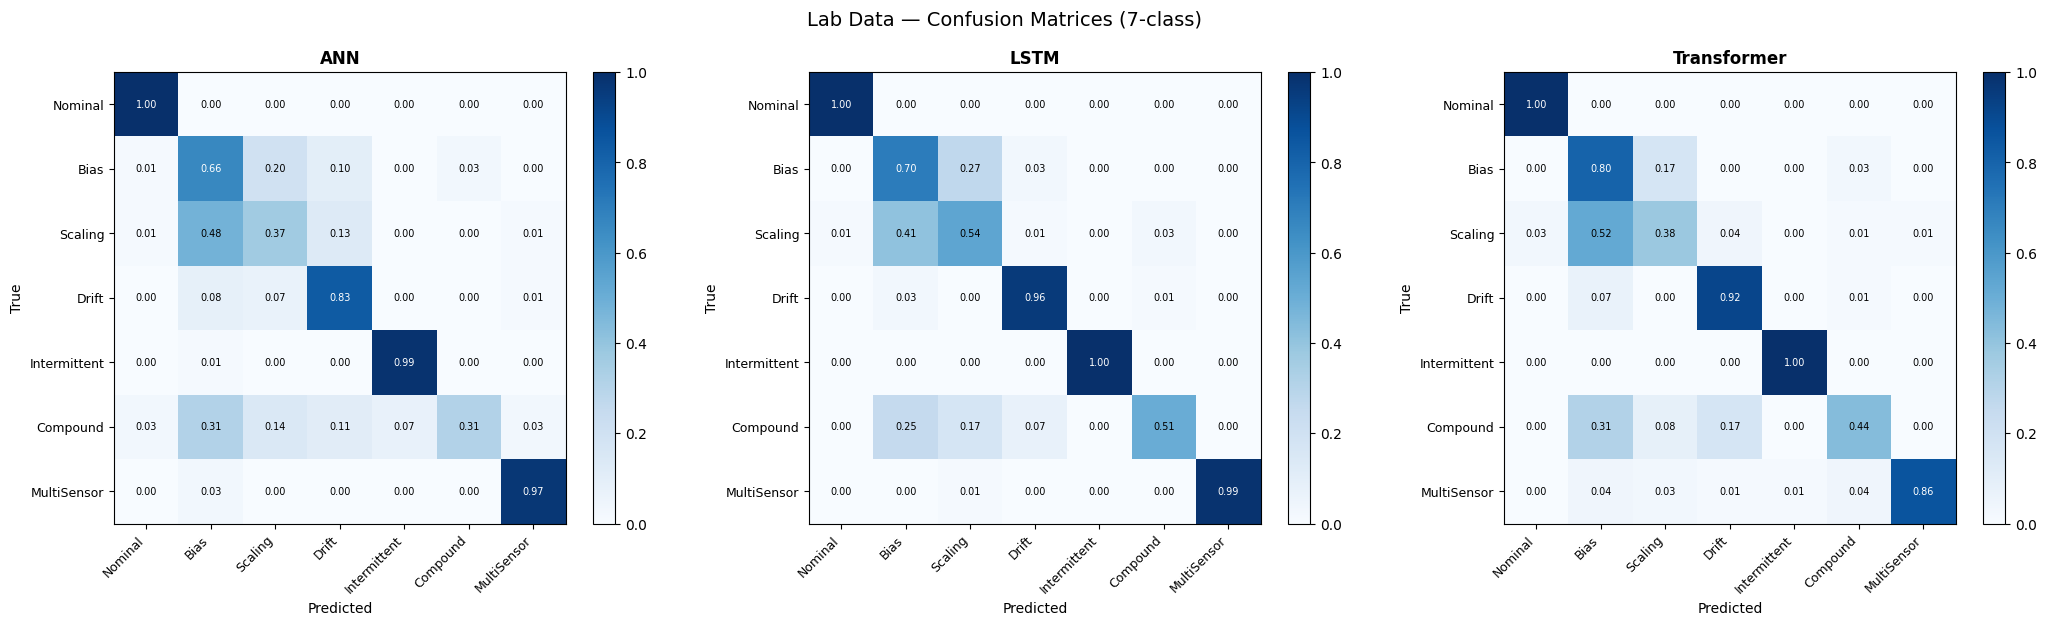

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import itertools

true_labels = y_fault[idx_test]
class_names = [label_names[i] for i in range(N_FAULT_TYPES)]

model_preds = {name: res['fault']['pred_class'].cpu().numpy()
               for name, res in mc_results.items()}

for name, preds in model_preds.items():
    print(f'\n{"="*55}')
    print(f'  {name}  — Classification Report')
    print(f'{"="*55}')
    print(classification_report(
        true_labels, preds,
        labels      = list(range(N_FAULT_TYPES)),
        target_names= class_names,
        zero_division= 0,
    ))

# Confusion matrices
n_models = len(model_preds)
if n_models > 0:
    fig, axes = plt.subplots(1, n_models, figsize=(7*n_models, 6), squeeze=False)
    for col, (name, preds) in enumerate(model_preds.items()):
        cm = confusion_matrix(true_labels, preds, labels=list(range(N_FAULT_TYPES)))
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True).clip(min=1)
        im = axes[0, col].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
        axes[0, col].set_xticks(range(len(class_names)))
        axes[0, col].set_yticks(range(len(class_names)))
        axes[0, col].set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
        axes[0, col].set_yticklabels(class_names, fontsize=9)
        axes[0, col].set_title(f'{name}', fontsize=12, fontweight='bold')
        axes[0, col].set_xlabel('Predicted'); axes[0, col].set_ylabel('True')
        for i, j in itertools.product(range(len(class_names)), repeat=2):
            axes[0, col].text(j, i, f'{cm_norm[i,j]:.2f}',
                              ha='center', va='center', fontsize=7,
                              color='white' if cm_norm[i,j] > 0.6 else 'black')
        plt.colorbar(im, ax=axes[0, col], fraction=0.046)
    plt.suptitle('Lab Data — Confusion Matrices (7-class)', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'{PLOT_DIR}/nb3_lab_confusion.png', dpi=130, bbox_inches='tight')
    plt.show()

## 8 — Save metadata for NB4/NB5

In [13]:
nb3_meta = {
    'head_type'     : HEAD_TYPE,
    'use_residual'  : USE_RESIDUAL,
    'n_sensors'     : N_SENSORS,
    'window_size'   : WINDOW_SIZE,
    'n_fault_types' : N_FAULT_TYPES,
    'n_sensor_cols' : len(sensor_cols),
    'lstm_config': {
        'hidden_size': LSTM_HIDDEN, 'num_layers': LSTM_LAYERS,
        'dropout_p': DROPOUT_P_ANN,
    } if HEAD_TYPE in ('LSTM', 'all') else None,
    'transformer_config': {
        'd_model': TF_D_MODEL, 'nhead': TF_NHEAD,
        'num_layers': TF_LAYERS, 'dim_feedforward': TF_FFN_DIM,
        'dropout_p': DROPOUT_P_SEQ,
    } if HEAD_TYPE in ('Transformer', 'all') else None,
    'best_val_losses': {
        k: float(min(v[0])) for k, v in
        [('ANN', (ann_val_losses,)), ('LSTM', (lstm_val_losses,)),
         ('Transformer', (tf_val_losses,))]
        if v[0] is not None
    },
}

with open(f'{CKPT_DIR}/nb3_meta.json', 'w') as f:
    json.dump(nb3_meta, f, indent=2)

print('Saved nb3_meta.json')
print(json.dumps(nb3_meta, indent=2))
print('\n✓ NB3 complete — Proceed to NB4_SHAP.ipynb')

Saved nb3_meta.json
{
  "head_type": "all",
  "use_residual": true,
  "n_sensors": 29,
  "window_size": 100,
  "n_fault_types": 7,
  "n_sensor_cols": 29,
  "lstm_config": {
    "hidden_size": 64,
    "num_layers": 2,
    "dropout_p": 0.3
  },
  "transformer_config": {
    "d_model": 32,
    "nhead": 4,
    "num_layers": 2,
    "dim_feedforward": 128,
    "dropout_p": 0.1
  },
  "best_val_losses": {
    "ANN": 0.893088698387146,
    "LSTM": 0.5769222974777222,
    "Transformer": 0.9102692604064941
  }
}

✓ NB3 complete — Proceed to NB4_SHAP.ipynb


---
## ↻ Reload Block

In [14]:
import sys, os, gc, pickle, warnings, json
import numpy as np, torch
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')
from models import (ConvAutoencoder, AETrainer, MultiHeadANN, ANNTrainer,
                    MultiHeadLSTM, MultiHeadTransformer, SequenceTrainer,
                    MCDropoutWrapper, DEVICE)
from feature_engineering import FeaturePipeline
from lab_data_utils import LAB_FAULT_LABELS

PROC_DIR = '../processed_data'; CKPT_DIR = '../checkpoints'; PLOT_DIR = '../plots'
label_names = LAB_FAULT_LABELS

with open(f'{PROC_DIR}/sensor_cols.pkl', 'rb') as f: sensor_cols = pickle.load(f)
with open(f'{CKPT_DIR}/nb3_meta.json')          as f: meta3 = json.load(f)

HEAD_TYPE = meta3['head_type']; USE_RESIDUAL = meta3['use_residual']
N_SENSORS = meta3['n_sensors']; WINDOW_SIZE = meta3['window_size']
N_FAULT_TYPES = meta3['n_fault_types']

_raw = np.load(f'{PROC_DIR}/augmented_dataset_with_recon.npz')
X_dataset = _raw['X']; X_recon_all = _raw['X_rec']
y_fault = _raw['y_f']; y_sensor = _raw['y_s']; y_mag = _raw['y_m']

ae_model = ConvAutoencoder(n_sensors=N_SENSORS, window_size=WINDOW_SIZE,
                            base_ch=16, latent_dim=32, dropout_p=0.20).to(DEVICE)
ae_model.load_state_dict(torch.load(f'{CKPT_DIR}/autoencoder.pt',
                                     map_location=DEVICE, weights_only=True))
ae_model.eval(); ae_trainer = AETrainer(ae_model, device=DEVICE)

if HEAD_TYPE in ('ANN', 'all') and os.path.exists(f'{CKPT_DIR}/ann_multihead.pt'):
    _d = np.load(f'{PROC_DIR}/final_manifold_features.npz')
    F_all = _d['F']
    with open(f'{CKPT_DIR}/feature_pipeline.pkl', 'rb') as f: feat_pipe = pickle.load(f)
    ann_model = MultiHeadANN(in_features=F_all.shape[1], n_fault_types=N_FAULT_TYPES,
                              n_sensors=len(sensor_cols), hidden_dims=[128,64,32], dropout_p=0.3)
    ann_model.load_state_dict(torch.load(f'{CKPT_DIR}/ann_multihead.pt',
                                          map_location=DEVICE, weights_only=True))
    ann_model.to(DEVICE).eval()

if HEAD_TYPE in ('LSTM', 'all') and os.path.exists(f'{CKPT_DIR}/lstm_multihead.pt'):
    cfg = meta3['lstm_config']
    lstm_model = MultiHeadLSTM(n_sensors=N_SENSORS, hidden_size=cfg['hidden_size'],
                                num_layers=cfg['num_layers'], n_fault_types=N_FAULT_TYPES,
                                dropout_p=cfg['dropout_p'], use_residual=USE_RESIDUAL)
    lstm_model.load_state_dict(torch.load(f'{CKPT_DIR}/lstm_multihead.pt',
                                           map_location=DEVICE, weights_only=True))
    lstm_model.to(DEVICE).eval()

if HEAD_TYPE in ('Transformer', 'all') and os.path.exists(f'{CKPT_DIR}/transformer_multihead.pt'):
    cfg = meta3['transformer_config']
    tf_model = MultiHeadTransformer(n_sensors=N_SENSORS, d_model=cfg['d_model'],
                                     nhead=cfg['nhead'], num_layers=cfg['num_layers'],
                                     dim_feedforward=cfg['dim_feedforward'],
                                     n_fault_types=N_FAULT_TYPES, dropout_p=cfg['dropout_p'],
                                     use_residual=USE_RESIDUAL, store_attn=True)
    tf_model.load_state_dict(torch.load(f'{CKPT_DIR}/transformer_multihead.pt',
                                         map_location=DEVICE, weights_only=True))
    tf_model.to(DEVICE).eval()

print(f'✓ All reloaded  [{HEAD_TYPE} | {N_FAULT_TYPES} classes | {N_SENSORS} sensors]')

2026-04-22 14:18:26,620 [INFO] AE Bottleneck: 1664 -> 32 -> 1664


✓ All reloaded  [all | 7 classes | 29 sensors]


## EVAL-B — Full Classification Report (All Models)

In [17]:
# ─── Full Classification Report — All Models ──────────────────────────────
from sklearn.metrics import classification_report, accuracy_score

true_labels = y_fault[idx_test]
class_names = [label_names[i] for i in range(N_FAULT_TYPES)]

model_preds = {}
if "ANN"         in mc_results: model_preds["ANN"]         = mc_results["ANN"]["fault"]["pred_class"].cpu().numpy()
if "LSTM"        in mc_results: model_preds["LSTM"]        = mc_results["LSTM"]["fault"]["pred_class"].cpu().numpy()
if "Transformer" in mc_results: model_preds["Transformer"] = mc_results["Transformer"]["fault"]["pred_class"].cpu().numpy()

for model_name, preds in model_preds.items():
    acc = accuracy_score(true_labels, preds)
    W   = 62
    print()
    print("╔" + "═"*W + "╗")
    print(f"║  {('SVF FRAMEWORK — ' + model_name + ' CLASSIFIER'):^{W-2}}  ║")
    print(f"║  {'Overall Accuracy: ' + f'{acc*100:.2f}%':^{W-2}}  ║")
    print("╠" + "═"*W + "╣")
    print(f"║  {'Class':<18} {'Precision':>9} {'Recall':>9} {'F1-Score':>9} {'Support':>8}  ║")
    print("╠" + "═"*W + "╣")
    rd = classification_report(true_labels, preds, labels=list(range(N_FAULT_TYPES)),
                                target_names=class_names, output_dict=True, zero_division=0)
    for cname in class_names:
        r = rd[cname]
        print(f"║  {cname:<18} {r['precision']:>9.3f} {r['recall']:>9.3f} {r['f1-score']:>9.3f} {int(r['support']):>8}  ║")
    print("╠" + "═"*W + "╣")
    r = rd["macro avg"]
    print(f"║  {'Macro avg':<18} {r['precision']:>9.3f} {r['recall']:>9.3f} {r['f1-score']:>9.3f} {int(r['support']):>8}  ║")
    r = rd["weighted avg"]
    print(f"║  {'Weighted avg':<18} {r['precision']:>9.3f} {r['recall']:>9.3f} {r['f1-score']:>9.3f} {int(r['support']):>8}  ║")
    print("╝" + "═"*W + "╚")
    print()


╔══════════════════════════════════════════════════════════════╗
║                 SVF FRAMEWORK — ANN CLASSIFIER                 ║
║                    Overall Accuracy: 73.40%                    ║
╠══════════════════════════════════════════════════════════════╣
║  Class              Precision    Recall  F1-Score  Support  ║
╠══════════════════════════════════════════════════════════════╣
║  Nominal                0.947     1.000     0.973       71  ║
║  Bias                   0.420     0.662     0.514       71  ║
║  Scaling                0.473     0.366     0.413       71  ║
║  Drift                  0.714     0.833     0.769       72  ║
║  Intermittent           0.934     0.986     0.959       72  ║
║  Compound               0.917     0.310     0.463       71  ║
║  MultiSensor            0.946     0.972     0.959       72  ║
╠══════════════════════════════════════════════════════════════╣
║  Macro avg              0.764     0.733     0.721      500  ║
║  Weighted avg           0.7

## EVAL-C — Confusion Matrix + F1 Bar Chart (per model)

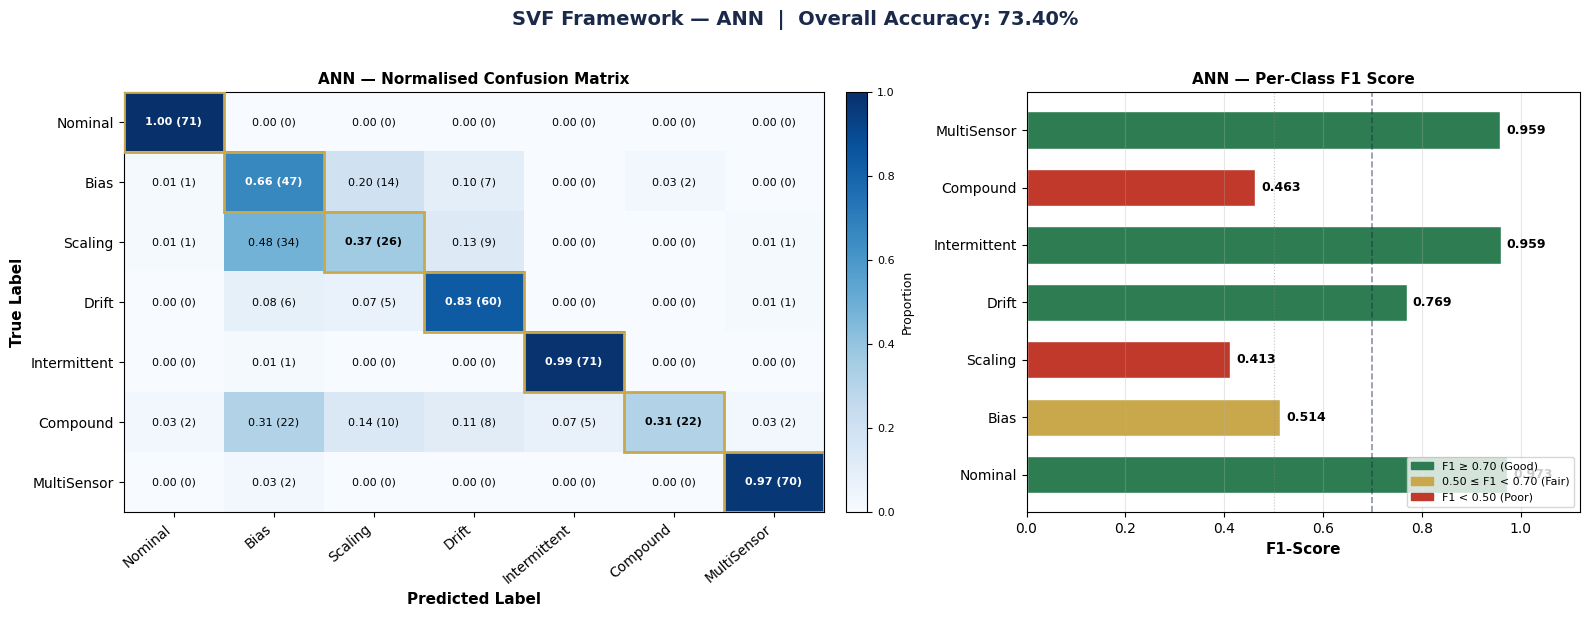

Saved: ../plots/nb3_lab_confusion_ann.png


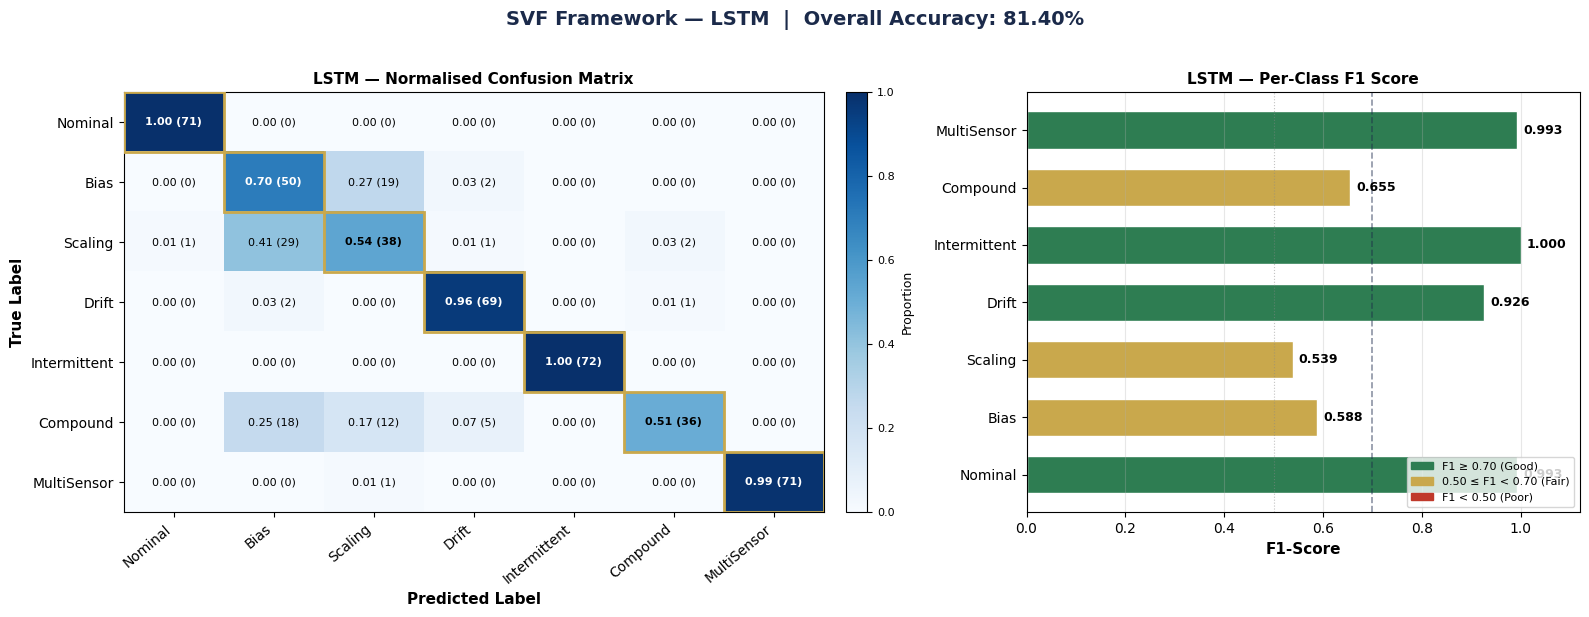

Saved: ../plots/nb3_lab_confusion_lstm.png


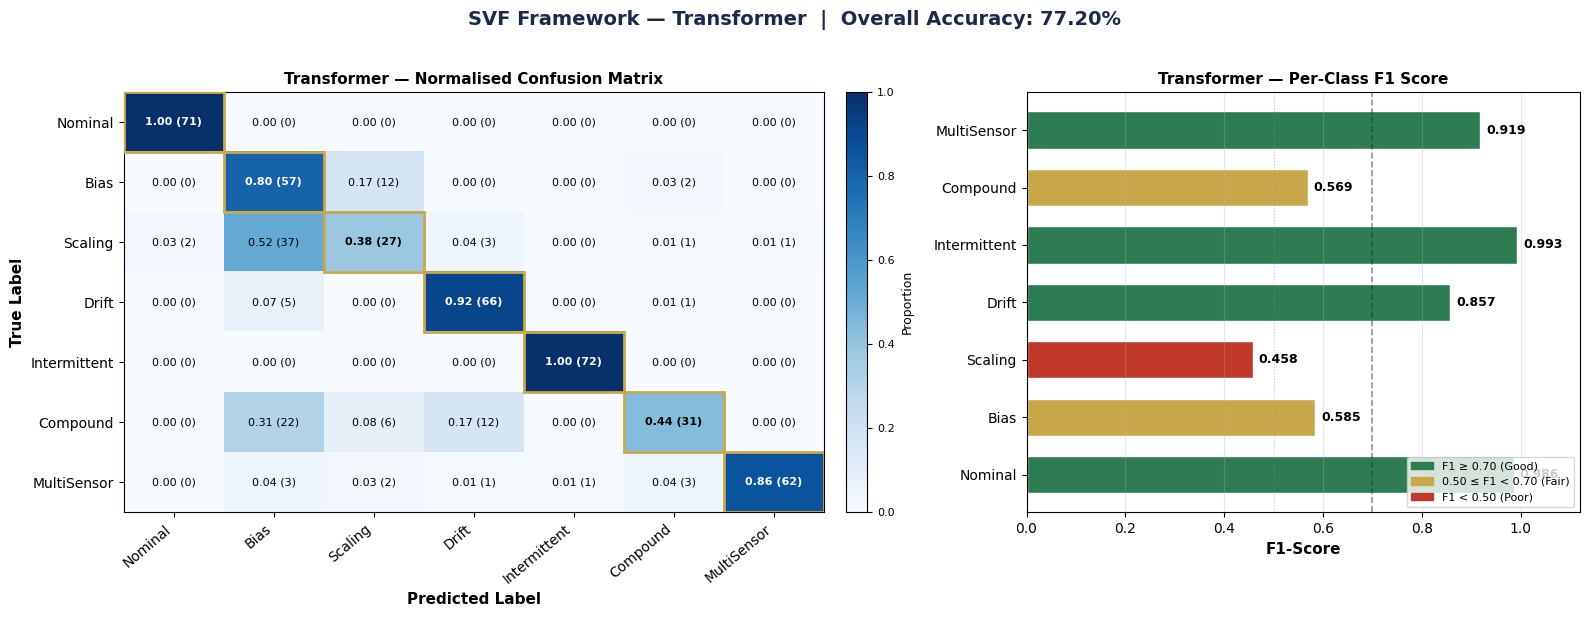

Saved: ../plots/nb3_lab_confusion_transformer.png


In [18]:
# ─── Confusion Matrices + F1 Bars — All Models ────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, itertools
from sklearn.metrics import confusion_matrix, f1_score

true_labels = y_fault[idx_test]
class_names = [label_names[i] for i in range(N_FAULT_TYPES)]
NAVY, GOLD  = "#1B2A4A", "#C9A84C"

for model_name, preds in model_preds.items():
    cm      = confusion_matrix(true_labels, preds, labels=list(range(N_FAULT_TYPES)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    acc     = np.diag(cm).sum() / cm.sum()
    f1_pc   = f1_score(true_labels, preds, labels=list(range(N_FAULT_TYPES)),
                       average=None, zero_division=0)

    fig, axes = plt.subplots(1, 2, figsize=(16,6),
                              gridspec_kw={"width_ratios":[1.15, 0.85]})
    fig.suptitle(f"SVF Framework — {model_name}  |  Overall Accuracy: {acc*100:.2f}%",
                 fontsize=14, fontweight="bold", color=NAVY, y=1.02)

    # Left: confusion matrix
    ax = axes[0]
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(N_FAULT_TYPES)); ax.set_yticks(range(N_FAULT_TYPES))
    ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=10)
    ax.set_yticklabels(class_names, fontsize=10)
    ax.set_xlabel("Predicted Label", fontsize=11, fontweight="bold")
    ax.set_ylabel("True Label",      fontsize=11, fontweight="bold")
    ax.set_title(f"{model_name} — Normalised Confusion Matrix",
                 fontsize=11, fontweight="bold")
    for i,j in itertools.product(range(N_FAULT_TYPES), range(N_FAULT_TYPES)):
        nrm,raw = cm_norm[i,j], cm[i,j]
        ax.text(j,i, f"{nrm:.2f} ({raw})", ha="center", va="center", fontsize=8,
                color="white" if nrm>0.55 else "black",
                fontweight="bold" if i==j else "normal")
    for k in range(N_FAULT_TYPES):
        ax.add_patch(plt.Rectangle((k-0.5,k-0.5),1,1,fill=False,
                                    edgecolor=GOLD,linewidth=2.0,zorder=3))
    cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
    cbar.set_label("Proportion", fontsize=9); cbar.ax.tick_params(labelsize=8)

    # Right: per-class F1 bars
    ax2   = axes[1]
    ypos  = np.arange(N_FAULT_TYPES)
    cols  = ["#2E7D52" if f>=0.70 else "#C9A84C" if f>=0.50 else "#C0392B" for f in f1_pc]
    bars  = ax2.barh(ypos, f1_pc, color=cols, edgecolor="white", height=0.65)
    ax2.set_yticks(ypos); ax2.set_yticklabels(class_names, fontsize=10)
    ax2.set_xlabel("F1-Score", fontsize=11, fontweight="bold")
    ax2.set_xlim(0, 1.12)
    ax2.set_title(f"{model_name} — Per-Class F1 Score", fontsize=11, fontweight="bold")
    ax2.axvline(0.70, color=NAVY, lw=1.2, ls="--", alpha=0.5)
    ax2.axvline(0.50, color="#888", lw=0.8, ls=":", alpha=0.5)
    ax2.grid(axis="x", alpha=0.3)
    for bar,f1 in zip(bars,f1_pc):
        ax2.text(bar.get_width()+0.012, bar.get_y()+bar.get_height()/2,
                 f"{f1:.3f}", va="center", ha="left", fontsize=9, fontweight="bold")
    patches = [mpatches.Patch(color="#2E7D52",label="F1 ≥ 0.70 (Good)"),
               mpatches.Patch(color="#C9A84C",label="0.50 ≤ F1 < 0.70 (Fair)"),
               mpatches.Patch(color="#C0392B",label="F1 < 0.50 (Poor)")]
    ax2.legend(handles=patches, fontsize=8, loc="lower right")

    plt.tight_layout()
    fname = f"{PLOT_DIR}/nb3_lab_confusion_{model_name.lower()}.png"
    plt.savefig(fname, dpi=130, bbox_inches="tight"); plt.show()
    print(f"Saved: {fname}")

## EVAL-D — Framework Summary: All Models Comparison


╔══════════════════════════════════════════════════════════════════╗
║           SVF FRAMEWORK — COMPLETE PERFORMANCE SUMMARY           ║
╠══════════════════════════════════════════════════════════════════╣
║  Metric                           ANN          LSTM   Transformer  ║
╠══════════════════════════════════════════════════════════════════╣
║  Overall Accuracy              73.40%        81.40%        77.20%  ║
║  Macro F1                      0.7214        0.8134        0.7666  ║
║  Weighted F1                   0.7224        0.8144        0.7675  ║
║  Macro Precision               0.7643        0.8362        0.7997  ║
║  Macro Recall                  0.7328        0.8130        0.7711  ║
║  MC Confidence                 0.6417        0.8128        0.7729  ║
╠══════════════════════════════════════════════════════════════════╣
║  Per-Class F1                                                      ║
╠══════════════════════════════════════════════════════════════════╣
║    Nominal     

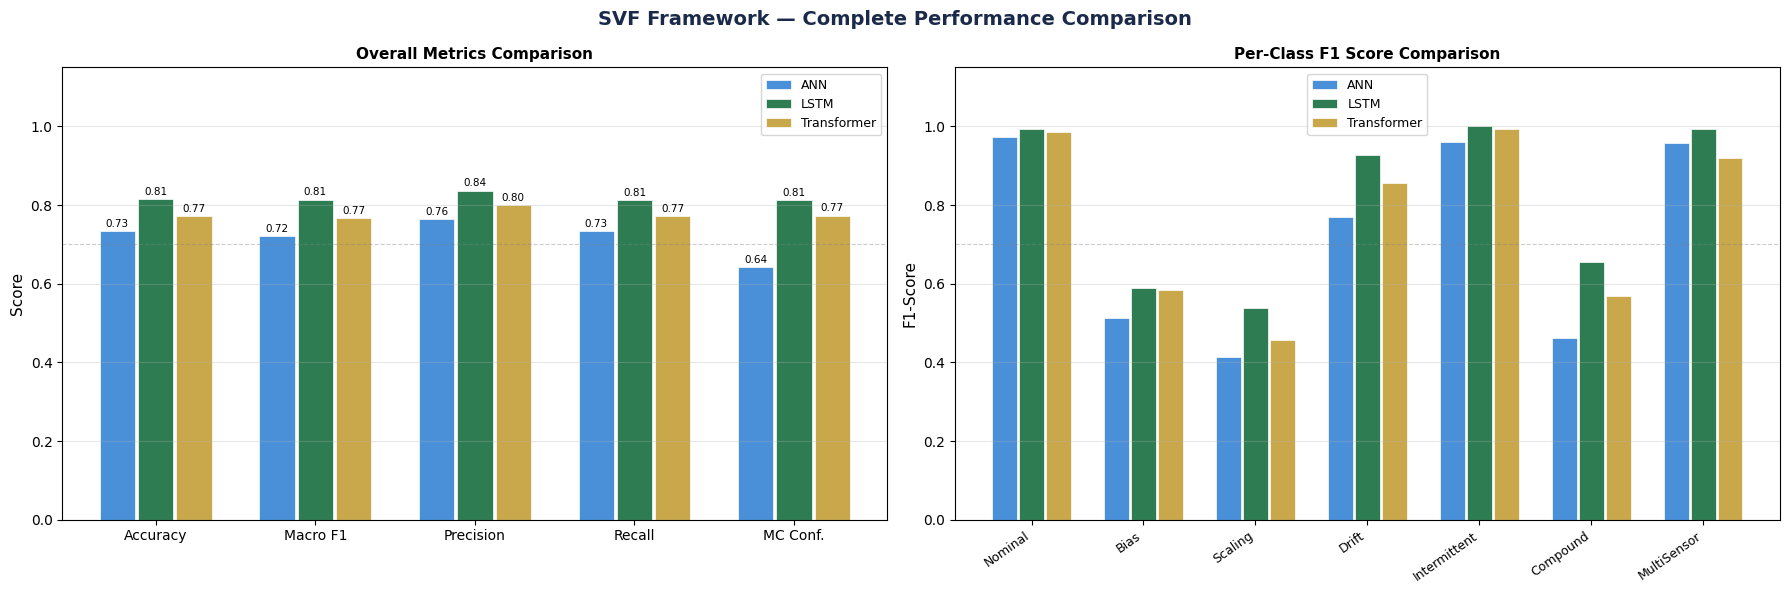

Saved: ../plots/nb3_lab_framework_summary.png


In [19]:
# ─── Framework Summary Table + Comparison Charts ──────────────────────────
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score)

true_labels = y_fault[idx_test]
class_names = [label_names[i] for i in range(N_FAULT_TYPES)]
NAVY, GOLD  = "#1B2A4A", "#C9A84C"

summary = {}
for mname, preds in model_preds.items():
    conf = mc_results[mname]["fault"]["confidence"].cpu().numpy()
    summary[mname] = {
        "accuracy"       : accuracy_score(true_labels, preds),
        "macro_f1"       : f1_score(true_labels, preds, average="macro",    zero_division=0),
        "weighted_f1"    : f1_score(true_labels, preds, average="weighted", zero_division=0),
        "macro_precision": precision_score(true_labels, preds, average="macro", zero_division=0),
        "macro_recall"   : recall_score(true_labels, preds, average="macro",    zero_division=0),
        "mc_confidence"  : float(conf.mean()),
        "f1_per_class"   : f1_score(true_labels, preds, labels=list(range(N_FAULT_TYPES)),
                                     average=None, zero_division=0),
    }

# Print summary table
mlist = list(summary.keys())
W = 24 + len(mlist)*14
print(); print("╔"+"═"*W+"╗")
print(f"║{'SVF FRAMEWORK — COMPLETE PERFORMANCE SUMMARY':^{W}}║")
print("╠"+"═"*W+"╣")
print(f"║  {'Metric':<22}" + "".join(f"{m:>14}" for m in mlist)+"  ║")
print("╠"+"═"*W+"╣")
rows = [("Overall Accuracy","accuracy",lambda v:f"{v*100:.2f}%"),
        ("Macro F1","macro_f1",lambda v:f"{v:.4f}"),
        ("Weighted F1","weighted_f1",lambda v:f"{v:.4f}"),
        ("Macro Precision","macro_precision",lambda v:f"{v:.4f}"),
        ("Macro Recall","macro_recall",lambda v:f"{v:.4f}"),
        ("MC Confidence","mc_confidence",lambda v:f"{v:.4f}")]
for label,key,fmt in rows:
    print(f"║  {label:<22}"+"".join(f"{fmt(summary[m][key]):>14}" for m in mlist)+"  ║")
print("╠"+"═"*W+"╣")
print(f"║  {'Per-Class F1':<22}"+" "*len(mlist)*14+"  ║")
print("╠"+"═"*W+"╣")
for ci,cname in enumerate(class_names):
    print(f"║  {'  '+cname:<22}"+"".join(f"{summary[m]['f1_per_class'][ci]:>14.4f}" for m in mlist)+"  ║")
print("╝"+"═"*W+"╚")

# Figure: side-by-side comparison charts
mcols = {"ANN":"#4A90D9","LSTM":"#2E7D52","Transformer":"#C9A84C"}
dcols = ["#4A90D9","#2E7D52","#C9A84C","#C0392B"]

fig, axes = plt.subplots(1,2,figsize=(18,6))
fig.suptitle("SVF Framework — Complete Performance Comparison",
             fontsize=14,fontweight="bold",color=NAVY)

# Left: scalar metrics
ax = axes[0]
mlabels = ["Accuracy","Macro F1","Precision","Recall","MC Conf."]
mkeys   = ["accuracy","macro_f1","macro_precision","macro_recall","mc_confidence"]
x = np.arange(len(mlabels)); n = len(mlist); width = 0.72/n
for mi,mname in enumerate(mlist):
    vals   = [summary[mname][k] for k in mkeys]
    color  = mcols.get(mname, dcols[mi])
    offset = (mi - n/2 + 0.5)*width
    bars   = ax.bar(x+offset, vals, width=width*0.92,
                    color=color, label=mname, edgecolor="white", linewidth=0.5)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(mlabels, fontsize=10)
ax.set_ylabel("Score",fontsize=11); ax.set_ylim(0,1.15)
ax.set_title("Overall Metrics Comparison",fontsize=11,fontweight="bold")
ax.legend(fontsize=9); ax.grid(axis="y",alpha=0.3)
ax.axhline(0.70,color="gray",lw=0.8,ls="--",alpha=0.4)

# Right: per-class F1
ax2 = axes[1]
x2 = np.arange(N_FAULT_TYPES)
for mi,mname in enumerate(mlist):
    f1v    = summary[mname]["f1_per_class"]
    color  = mcols.get(mname, dcols[mi])
    offset = (mi - n/2 + 0.5)*width
    ax2.bar(x2+offset, f1v, width=width*0.92,
            color=color, label=mname, edgecolor="white", linewidth=0.5)
ax2.set_xticks(x2); ax2.set_xticklabels(class_names, rotation=35, ha="right", fontsize=9)
ax2.set_ylabel("F1-Score",fontsize=11); ax2.set_ylim(0,1.15)
ax2.set_title("Per-Class F1 Score Comparison",fontsize=11,fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(axis="y",alpha=0.3)
ax2.axhline(0.70,color="gray",lw=0.8,ls="--",alpha=0.4)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/nb3_lab_framework_summary.png",dpi=130,bbox_inches="tight")
plt.show(); print(f"Saved: {PLOT_DIR}/nb3_lab_framework_summary.png")